In [1]:
! dir dataset

 Volume in drive C is Windows
 Volume Serial Number is CADF-5C02

 Directory of c:\Users\Umar Aftab\Projects\skin-cancer-detection\dataset

05/03/2026  08:53 AM    <DIR>          .
05/03/2026  09:05 AM    <DIR>          ..
05/03/2026  08:41 AM    <DIR>          HAM10000_images_part_1
05/03/2026  08:42 AM    <DIR>          HAM10000_images_part_2
10/06/2019  04:59 PM           563,277 HAM10000_metadata.csv
10/06/2019  05:03 PM        30,807,979 hmnist_28_28_L.csv
10/06/2019  05:03 PM        91,820,383 hmnist_28_28_RGB.csv
10/06/2019  05:03 PM         2,537,778 hmnist_8_8_L.csv
10/06/2019  05:03 PM         7,524,968 hmnist_8_8_RGB.csv
               5 File(s)    133,254,385 bytes
               4 Dir(s)  55,833,903,104 bytes free


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cuda


In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Define base paths (adjust if you are running locally instead of Kaggle)
base_dir = 'dataset'
csv_path = os.path.join(base_dir, 'HAM10000_metadata.csv')

In [4]:
# Cell 2: Load metadata and map image paths
df = pd.read_csv(csv_path)

# Create a dictionary mapping image_id to the actual file path
image_paths = {}
for part in ['HAM10000_images_part_1', 'HAM10000_images_part_2']:
    folder_path = os.path.join(base_dir, part)
    if os.path.exists(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith('.jpg'):
                image_id = os.path.splitext(file)[0]
                image_paths[image_id] = os.path.join(folder_path, file)

# Add the file path to the dataframe
df['path'] = df['image_id'].map(image_paths)

# Map the short 'dx' codes to their full medical names for clarity
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}
df['cell_type'] = df['dx'].map(lesion_type_dict)

print(f"Total records loaded: {len(df)}")
display(df.sample(10))

Total records loaded: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type
2792,HAM_0004967,ISIC_0028815,bcc,histo,70.0,female,face,dataset\HAM10000_images_part_1\ISIC_0028815.jpg,Basal cell carcinoma
5540,HAM_0003784,ISIC_0027965,nv,follow_up,50.0,male,back,dataset\HAM10000_images_part_1\ISIC_0027965.jpg,Melanocytic nevi
3959,HAM_0000735,ISIC_0029492,nv,follow_up,40.0,female,abdomen,dataset\HAM10000_images_part_2\ISIC_0029492.jpg,Melanocytic nevi
2347,HAM_0007614,ISIC_0027672,vasc,histo,55.0,female,face,dataset\HAM10000_images_part_1\ISIC_0027672.jpg,Vascular lesions
2950,HAM_0004084,ISIC_0025285,bcc,histo,75.0,female,upper extremity,dataset\HAM10000_images_part_1\ISIC_0025285.jpg,Basal cell carcinoma
2668,HAM_0003600,ISIC_0031836,bcc,histo,40.0,female,abdomen,dataset\HAM10000_images_part_2\ISIC_0031836.jpg,Basal cell carcinoma
7562,HAM_0003542,ISIC_0033506,nv,histo,35.0,male,back,dataset\HAM10000_images_part_2\ISIC_0033506.jpg,Melanocytic nevi
5053,HAM_0002716,ISIC_0030779,nv,follow_up,65.0,male,lower extremity,dataset\HAM10000_images_part_2\ISIC_0030779.jpg,Melanocytic nevi
2277,HAM_0003509,ISIC_0031778,mel,histo,75.0,male,lower extremity,dataset\HAM10000_images_part_2\ISIC_0031778.jpg,Melanoma
1812,HAM_0001686,ISIC_0032698,mel,histo,65.0,male,face,dataset\HAM10000_images_part_2\ISIC_0032698.jpg,Melanoma


In [5]:
# Cell 3: Check for missing values
print("Dataset Info:")
print(df.info())
print("\nMissing values per column:")
print(df.isnull().sum())

# Age has a few missing values. For EDA, we can fill them with the mean age.
df['age'].fillna(df['age'].mean(), inplace=True)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           9958 non-null   float64
 5   sex           10015 non-null  str    
 6   localization  10015 non-null  str    
 7   path          10015 non-null  str    
 8   cell_type     10015 non-null  str    
dtypes: float64(1), str(8)
memory usage: 704.3 KB
None

Missing values per column:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
path             0
cell_type        0
dtype: int64


C:\Users\Umar Aftab\AppData\Local\Temp\ipykernel_2312\2923891934.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['age'].fillna(df['age'].mean(), inplace=True)


0        80.0
1        80.0
2        80.0
3        80.0
4        75.0
         ... 
10010    40.0
10011    40.0
10012    40.0
10013    80.0
10014    70.0
Name: age, Length: 10015, dtype: float64

C:\Users\Umar Aftab\AppData\Local\Temp\ipykernel_2312\2419918595.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='cell_type', order=df['cell_type'].value_counts().index, palette='viridis')


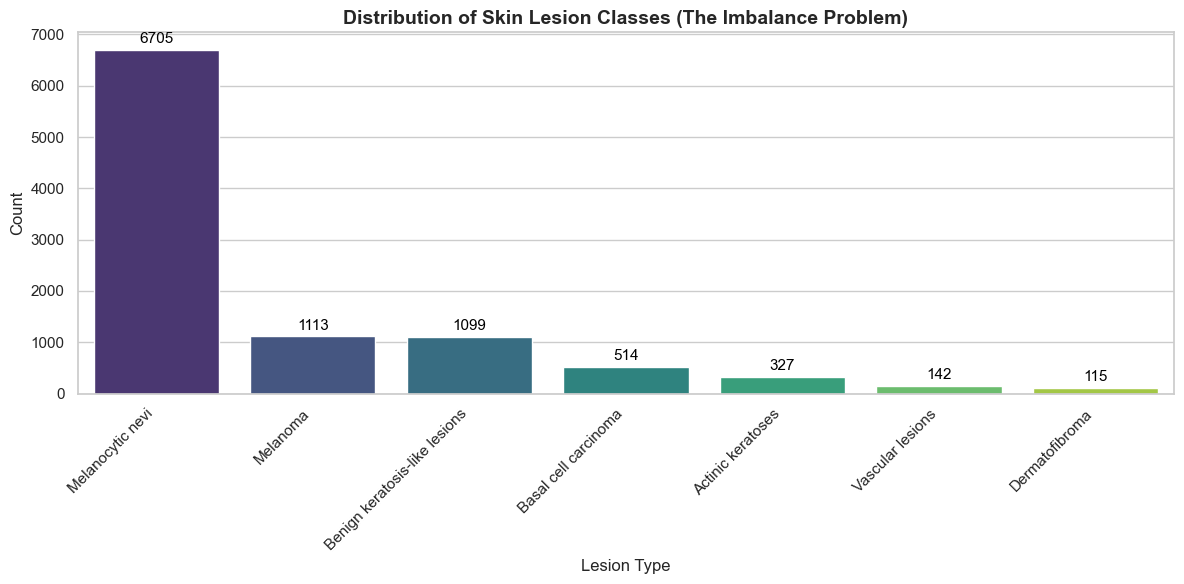

In [6]:
# Cell 4: Distribution of target classes
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x='cell_type', order=df['cell_type'].value_counts().index, palette='viridis')

# Add exact counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', 
                fontsize=11, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.title('Distribution of Skin Lesion Classes (The Imbalance Problem)', fontsize=14, fontweight='bold')
plt.xlabel('Lesion Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\Umar Aftab\AppData\Local\Temp\ipykernel_2312\2325564453.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=sex_data, x='sex', ax=axes[1], palette='pastel')


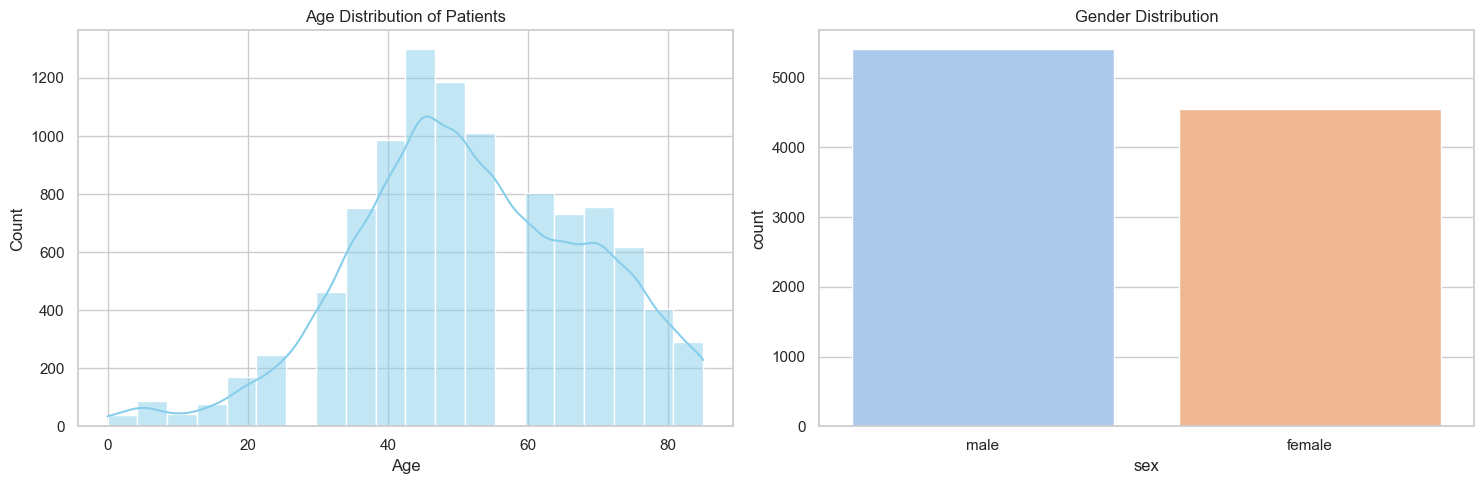

In [7]:
# Cell 5: Age and Sex Distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Age distribution
sns.histplot(df['age'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution of Patients')
axes[0].set_xlabel('Age')

# Sex distribution (excluding 'unknown')
sex_data = df[df['sex'] != 'unknown']
sns.countplot(data=sex_data, x='sex', ax=axes[1], palette='pastel')
axes[1].set_title('Gender Distribution')

plt.tight_layout()
plt.show()

C:\Users\Umar Aftab\AppData\Local\Temp\ipykernel_2312\3193314485.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='localization', data=df, order=df['localization'].value_counts().index, palette='crest')


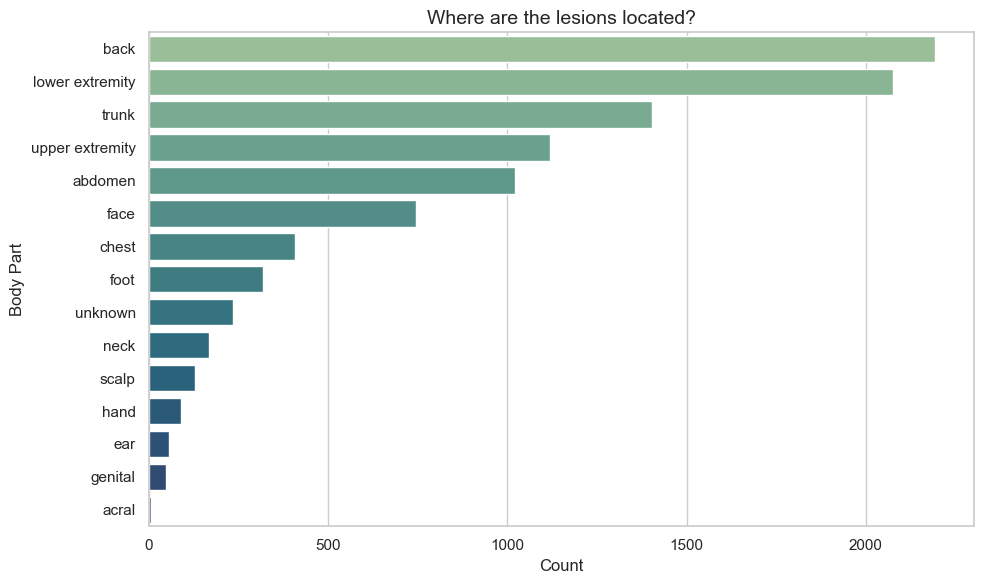

In [8]:
# Cell 6: Anatomical Localization of Lesions
plt.figure(figsize=(10, 6))
sns.countplot(y='localization', data=df, order=df['localization'].value_counts().index, palette='crest')
plt.title('Where are the lesions located?', fontsize=14)
plt.xlabel('Count')
plt.ylabel('Body Part')
plt.tight_layout()
plt.show()

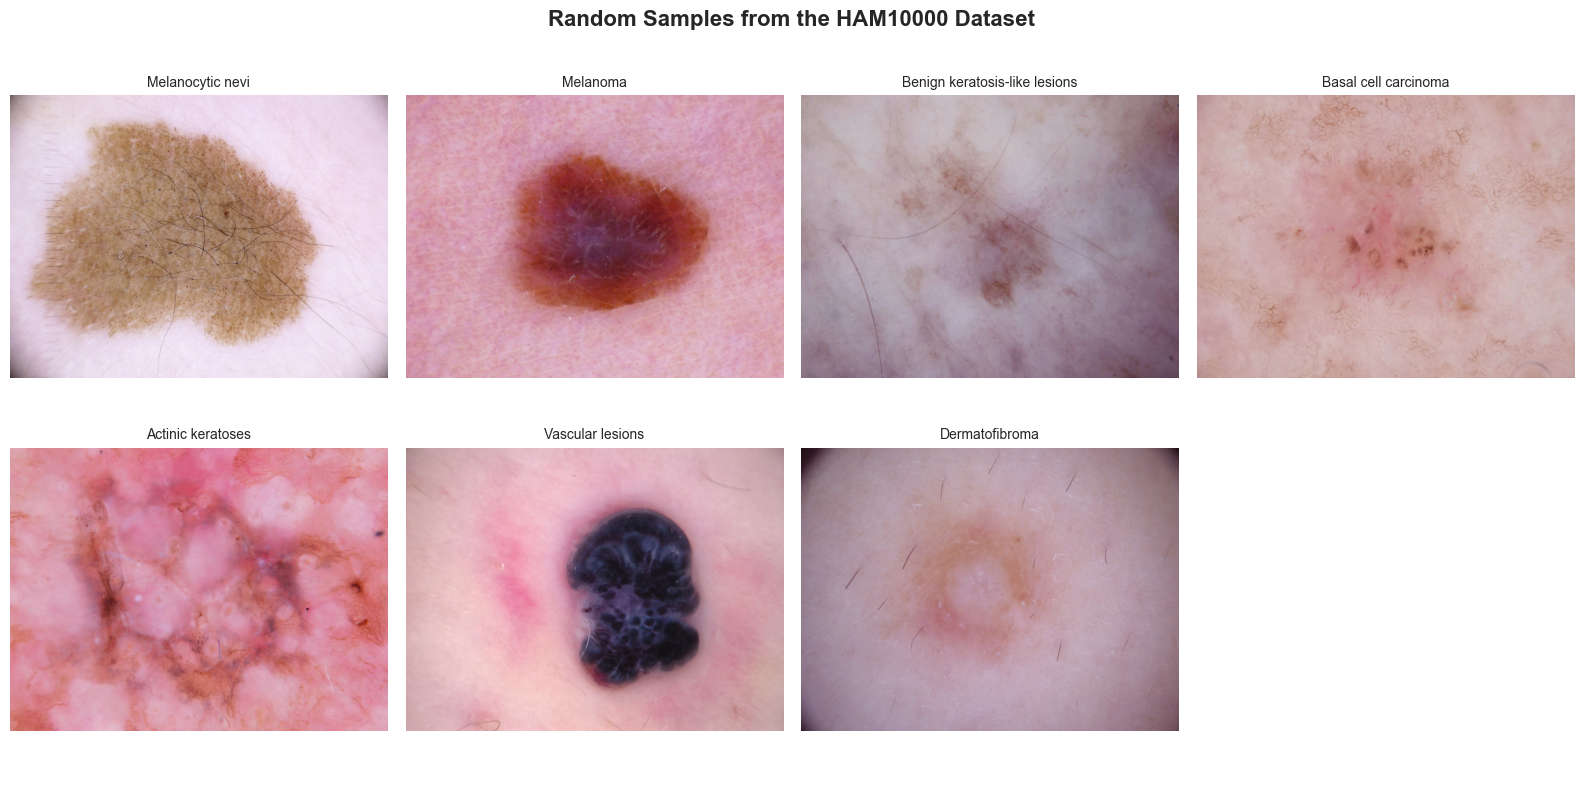

In [9]:
# Cell 7: Display one random sample from each class
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# Iterate through the unique classes
for i, (lesion_type, class_name) in enumerate(lesion_type_dict.items()):
    # Get a random image path for this class
    sample_path = df[df['dx'] == lesion_type]['path'].sample(1).values[0]
    
    # Load and display the image
    img = Image.open(sample_path)
    axes[i].imshow(img)
    axes[i].set_title(class_name, fontsize=10)
    axes[i].axis('off')

# Hide the empty 8th subplot
axes[7].axis('off')

plt.suptitle('Random Samples from the HAM10000 Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.isna().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
path             0
cell_type        0
dtype: int64

In [12]:
# --- Augmentation (stronger for rarer classes) ---
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, 
                           saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

In [13]:
# --- Dataset class that handles both image folders ---
class HAMDataset(Dataset):
    def __init__(self, df, img_dirs, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dirs = img_dirs
        self.transform = transform
        self.label_map = {
            'nv': 0,
            'mel': 1,
            'bkl': 2,
            'bcc': 3,
            'akiec': 4,
            'vasc': 5,
            'df': 6
        }

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.loc[idx, 'image_id']
        label = self.label_map[self.df.loc[idx, 'dx']]

        img_path = None

        # Search both folders for the image
        for d in self.img_dirs:
            p = os.path.join(d, img_id + '.jpg')
            if os.path.exists(p):
                img_path = p
                break

        # Fail loudly if the image path is wrong
        if img_path is None:
            raise FileNotFoundError(
                f"Image not found for image_id={img_id}. "
                f"Checked folders: {self.img_dirs}"
            )

        img = Image.open(img_path).convert('RGB')

        if self.transform:
            img = self.transform(img)

        return img, label

In [14]:
# Drop duplicate lesions (same lesion, multiple images)
df = df.drop_duplicates(subset='lesion_id')

train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df['dx'], random_state=42
)

# --- Oversample minority classes in train_df only ---
target_count = 2000
augmented_dfs = []

for cls in train_df['dx'].unique():
    cls_df = train_df[train_df['dx'] == cls]
    if len(cls_df) < target_count:
        # Oversample with replacement
        cls_df = cls_df.sample(target_count, replace=True, random_state=42)
    else:
        # Undersample nv to 2000 for balance
        cls_df = cls_df.sample(target_count, replace=False, random_state=42)
    augmented_dfs.append(cls_df)

balanced_train_df = pd.concat(augmented_dfs).sample(frac=1, random_state=42)
print(balanced_train_df['dx'].value_counts())  # should be ~2000 each

dx
mel      2000
vasc     2000
akiec    2000
bkl      2000
bcc      2000
df       2000
nv       2000
Name: count, dtype: int64


In [15]:
# Correct local dataset folders
img_dirs = [
    os.path.join(base_dir, 'HAM10000_images_part_1'),
    os.path.join(base_dir, 'HAM10000_images_part_2')
]

# Check that folders exist
for folder in img_dirs:
    print(folder, "exists:", os.path.exists(folder))

train_dataset = HAMDataset(
    balanced_train_df,
    img_dirs,
    transform=train_transforms
)

val_dataset = HAMDataset(
    val_df,
    img_dirs,
    transform=val_transforms
)

# IMPORTANT:
# Use num_workers=0 for local Windows/Jupyter to avoid DataLoader hanging.
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

dataset\HAM10000_images_part_1 exists: True
dataset\HAM10000_images_part_2 exists: True
Train: 14000 | Val: 1494


In [16]:
# Test whether DataLoader can load one batch successfully
imgs, labels = next(iter(train_loader))

print("Images batch shape:", imgs.shape)
print("Labels batch shape:", labels.shape)
print("Labels:", labels[:10])

Images batch shape: torch.Size([32, 3, 224, 224])
Labels batch shape: torch.Size([32])
Labels: tensor([2, 0, 0, 0, 4, 6, 3, 0, 5, 3])


In [17]:
label_map = {'nv':0, 'mel':1, 'bkl':2, 'bcc':3, 'akiec':4, 'vasc':5, 'df':6}

y_train = balanced_train_df['dx'].map(label_map).values

weights = compute_class_weight('balanced',
                                classes=np.array([0,1,2,3,4,5,6]),
                                y=y_train)

class_weights = torch.FloatTensor(weights).to(device)
print("Class weights:", class_weights)

Class weights: tensor([1., 1., 1., 1., 1., 1., 1.], device='cuda:0')


In [18]:
model = models.efficientnet_v2_m(weights='IMAGENET1K_V1', progress=True)

# Don't freeze anything — train the whole model
for param in model.parameters():
    param.requires_grad = True

# Replace classifier
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(model.classifier[1].in_features, 7)
)

model = model.to(device)

In [19]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adamax(model.parameters(), lr=0.0001, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5
)

In [20]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (imgs, labels) in enumerate(loader):
        if batch_idx % 20 == 0:
            print(f"Training batch {batch_idx + 1}/{len(loader)}")

        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100.0 * correct / total

    return epoch_loss, epoch_acc


def val_epoch(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_idx, (imgs, labels) in enumerate(loader):
            if batch_idx % 20 == 0:
                print(f"Validation batch {batch_idx + 1}/{len(loader)}")

            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100.0 * correct / total

    return epoch_loss, epoch_acc, all_preds, all_labels

In [21]:
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.counter = 0
        self.best_score = None

    def __call__(self, val_acc):
        if self.best_score is None or val_acc > self.best_score:
            self.best_score = val_acc
            self.counter = 0
            return False
        else:
            self.counter += 1
            print(f"  EarlyStopping: {self.counter}/{self.patience}")
            return self.counter >= self.patience

In [22]:
EPOCHS = 30

best_val_acc = 0.0
early_stopping = EarlyStopping(patience=5)

for epoch in range(EPOCHS):
    print("\n" + "=" * 60)
    print(f"Starting epoch {epoch + 1}/{EPOCHS}")
    print("=" * 60)

    train_loss, train_acc = train_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_acc, preds, labels = val_epoch(
        model,
        val_loader,
        criterion
    )

    scheduler.step(val_acc)

    current_lr = optimizer.param_groups[0]['lr']

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}% | "
        f"LR: {current_lr:.6f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"Best model saved with Val Acc: {val_acc:.2f}%")

    if early_stopping(val_acc):
        print("Early stopping triggered.")
        break

print(f"\nBest Val Accuracy: {best_val_acc:.2f}%")


Starting epoch 1/30
Training batch 1/438
Training batch 21/438
Training batch 41/438
Training batch 61/438
Training batch 81/438
Training batch 101/438
Training batch 121/438
Training batch 141/438
Training batch 161/438
Training batch 181/438
Training batch 201/438
Training batch 221/438


KeyboardInterrupt: 

In [ ]:
class_names = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']

model.load_state_dict(torch.load('best_model.pth'))
_, _, preds, true_labels = val_epoch(model, val_loader, criterion)

print(classification_report(true_labels, preds, target_names=class_names))
print("Balanced Accuracy:", balanced_accuracy_score(true_labels, preds))

In [ ]:
cm = confusion_matrix(true_labels, preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.title('Confusion Matrix - EfficientNet-B0')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()